https://www.kaggle.com/competitions/autismdiagnosis

https://colab.research.google.com/drive/1syuTC_e3dtBJLHh4nN04DpgS03cvqWHF#scrollTo=Q7OVB6KK5hV4

Cuộc thi AutismDiagnosis trên Kaggle là một bài toán học máy thuộc dạng Phân loại nhị phân (Binary Classification). Mục tiêu của mô hình là dự đoán xem một bệnh nhân có khả năng cao mắc Hội chứng tự kỷ (Autism Spectrum Disorder - ASD) hay không dựa trên các dữ liệu về hành vi, bảng hỏi sàng lọc và thông tin nhân khẩu học.

1. Cấu trúc các file dữ liệu   train.csv: Tập dữ liệu dùng để huấn luyện mô hình (bao gồm cả các đặc trưng và nhãn mục tiêu).   test.csv: Tập dữ liệu dùng để kiểm thử/dự đoán (chứa các đặc trưng nhưng không có nhãn mục tiêu, bạn phải dùng mô hình đã train để dự đoán nhãn này).   sample_submission.csv: File mẫu định dạng kết quả nộp bài lên Kaggle, đảm bảo đúng cấu trúc cột yêu cầu.   

2. Giải thích ý nghĩa các cột (Features)Dữ liệu bao gồm các thông tin khảo sát dựa trên bộ công cụ sàng lọc chứng tự kỷ (AQ - Autism Spectrum Quotient):ID: Mã định danh của bệnh nhân.   A1_Score đến A10_Score: Điểm số từ 10 câu hỏi sàng lọc hành vi/tâm lý (thường có giá trị nhị phân 0 hoặc 1, phản ánh các dấu hiệu đặc trưng liên quan đến tự kỷ).   result: Tổng điểm của bài kiểm tra sàng lọc từ câu A1 đến A10.   age: Tuổi của bệnh nhân (tính bằng năm).   age_desc: Phân loại hoặc mô tả chi tiết về độ tuổi của bệnh nhân.   gender: Giới tính của bệnh nhân.   ethnicity: Chủng tộc/dân tộc của bệnh nhân.   jaundice: Tiền sử bị bệnh vàng da (jaundice) lúc mới sinh hay không.   autism: Tiền sử gia đình có người thân trực hệ (bố, mẹ, anh chị em ruột) từng được chẩn đoán mắc chứng tự kỷ hay không.   contry_of_res: Quốc gia sinh sống của bệnh nhân.   used_app_before: Bệnh nhân đã từng sử dụng ứng dụng/bài kiểm tra sàng lọc này trước đây chưa.   relation: Mối quan hệ của người hoàn thành bảng khảo sát với bệnh nhân (ví dụ: tự làm, cha mẹ, người giám hộ, nhân viên y tế...).   

3. Cột mục tiêu (Target Column)Class/ASD: Đây là nhãn (label) cần dự đoán của bài toán.   0: Không mắc chứng tự kỷ (No).   1: Có dấu hiệu/mắc chứng tự kỷ (Yes).   

4. Mối liên hệ với đoạn code ở câu hỏi trước của bạn:Đoạn code bạn vừa hỏi hoàn toàn khớp để giải quyết bài toán này:LabelEncoder: Dùng để mã hóa các cột dạng chữ (như gender, ethnicity, contry_of_res, relation, age_desc) thành dạng số.SMOTE: Rất hữu ích nếu dữ liệu Class/ASD bị mất cân bằng (số lượng người không bị tự kỷ lớn hơn rất nhiều so với người bị tự kỷ).DecisionTreeClassifier / XGBoostClassifier: Các thuật toán phân loại mạnh mẽ để học quy luật từ các điểm số A1_Score - A10_Score và thông tin nhân khẩu học nhằm dự đoán cột Class/ASD.   

In [115]:
#import the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

1. Thư viện xử lý dữ liệu và tính toán cơ bản
import numpy as np: Nhập thư viện NumPy, dùng để tính toán số học, thao tác với mảng và ma trận đa chiều với hiệu suất cao. Viết tắt là np.

import pandas as pd: Nhập thư viện Pandas, công cụ chính để đọc, thao tác, phân tích và làm sạch dữ liệu dạng bảng (DataFrame). Viết tắt là pd.

2. Thư viện trực quan hóa dữ liệu (Vẽ biểu đồ)
import matplotlib.pyplot as plt: Nhập mô đun pyplot của Matplotlib để vẽ các biểu đồ cơ bản (biểu đồ đường, cột, tròn...). Viết tắt là plt.

import seaborn as sns: Nhập thư viện Seaborn (xây dựng dựa trên Matplotlib), giúp tạo ra các biểu đồ thống kê trực quan, đẹp mắt và dễ dàng hơn. Viết tắt là sns.

3. Tiền xử lý dữ liệu và xử lý mất cân bằng
from sklearn.preprocessing import LabelEncoder: Nhập công cụ LabelEncoder dùng để mã hóa các nhãn dạng chữ (text) thành dạng số nguyên (ví dụ: "Nam"/"Nữ" thành 0/1) để thuật toán học máy có thể đọc được.

from imblearn.over_sampling import SMOTE: Nhập thuật toán SMOTE từ thư viện imbalanced-learn, dùng để khắc phục tình trạng dữ liệu mất cân bằng (ví dụ: lớp A có 1000 mẫu nhưng lớp B chỉ có 50 mẫu) bằng cách tạo ra các điểm dữ liệu tổng hợp cho lớp ít mẫu hơn.

4. Chia dữ liệu, thuật toán và tối ưu hóa
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV: Nhập các công cụ hỗ trợ cho việc huấn luyện:

train_test_split: Chia tập dữ liệu thành tập huấn luyện (train) và tập kiểm thử (test).

cross_val_score: Đánh giá độ ổn định của mô hình qua nhiều phần dữ liệu khác nhau (cross-validation).

RandomizedSearchCV: Tự động tìm kiếm các tham số tốt nhất cho mô hình một cách ngẫu nhiên.

from sklearn.tree import DecisionTreeClassifier: Nhập thuật toán Cây quyết định (Decision Tree) dùng cho các bài toán phân loại.

from xgboost import XGBClassifier: Nhập thuật toán XGBoost (Extreme Gradient Boosting), một mô hình học máy cực kỳ mạnh mẽ và đạt hiệu suất cao dựa trên kỹ thuật boosting.

5. Đánh giá mô hình và Lưu trữ
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report: Nhập các hàm đo lường hiệu suất của mô hình phân loại:

accuracy_score: Tính tỷ lệ dự đoán đúng.

confusion_matrix: Tạo ma trận nhầm lẫn để xem mô hình đoán đúng/sai ở những lớp nào.

classification_report: In ra bảng báo cáo chi tiết gồm các chỉ số Precision, Recall và F1-score.

import pickle: Nhập thư viện Pickle chuẩn của Python, dùng để lưu (serialize) mô hình đã được huấn luyện ra file (.pkl) và nạp lại khi cần dự đoán dữ liệu mới mà không phải huấn luyện lại từ đầu.

In [116]:
import kagglehub
path = kagglehub.dataset_download("konikarani/autismdiagnosis")

Using Colab cache for faster access to the 'autismdiagnosis' dataset.


In [117]:
import os

# Đường dẫn thư mục con bên trong path
subfolder_path = os.path.join(path, "Autism_Prediction")

# Nếu thư mục Autism_Prediction tồn tại, kiểm tra nội dung bên trong nó
if os.path.exists(subfolder_path):
  print("Danh sách file trong Autism_Prediction:", os.listdir(subfolder_path))
  data_dir = subfolder_path
else:
  # Nếu không, duyệt toàn bộ các thư mục con để tìm file .csv
  data_dir = path
  for root, dirs, files in os.walk(path):
    if any(f.endswith(".csv") for f in files):
      data_dir = root
      break

print("Đường dẫn chứa file CSV thực tế:", data_dir)
print("Danh sách file:", os.listdir(data_dir))

# Tiến hành đọc file train và test từ data_dir chính xác
# (Kiểm tra chính xác tên file bằng cách in ra danh sách file ở trên, ví dụ: 'train.csv', 'test.csv' hoặc tên khác)
train_files = [f for f in os.listdir(data_dir) if "train" in f.lower()]
test_files = [f for f in os.listdir(data_dir) if "test" in f.lower()]

train_df = pd.read_csv(os.path.join(data_dir, train_files[0]))
test_df = pd.read_csv(os.path.join(data_dir, test_files[0]))

print("Kích thước tập Train:", train_df.shape)
print("Kích thước tập Test:", test_df.shape)
train_df.head()

Danh sách file trong Autism_Prediction: ['sample_submission.csv', 'train.csv', 'test.csv']
Đường dẫn chứa file CSV thực tế: /kaggle/input/autismdiagnosis/Autism_Prediction
Danh sách file: ['sample_submission.csv', 'train.csv', 'test.csv']
Kích thước tập Train: (800, 22)
Kích thước tập Test: (200, 21)


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [118]:
train_df.shape

(800, 22)

In [119]:
test_df.shape

(200, 21)

In [120]:
#display all columns of a dataframe
pd.set_option('display.max_columns', None)
#

In [121]:
train_df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [122]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [123]:
#convert age column datatype to integer
train_df["age"] = train_df["age"].astype(int)

In [124]:
train_df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [125]:
for col in train_df.columns:
  numerical_features = ["ID", "age", "result"]

  if col not in numerical_features:
    print(col, train_df[col].unique())
    print("-"*50)

A1_Score [1 0]
--------------------------------------------------
A2_Score [0 1]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [0 1]
--------------------------------------------------
A5_Score [1 0]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [0 1]
--------------------------------------------------
A9_Score [1 0]
--------------------------------------------------
A10_Score [1 0]
--------------------------------------------------
gender ['f' 'm']
--------------------------------------------------
ethnicity ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
--------------------------------------------------
jaundice ['no' 'yes']
--------------------------------------------------
austim

để kiểm tra các giá trị độc nhất (unique) của từng cột dạng phân loại (categorical) trong tập dữ liệu train_df, đồng thời loại trừ các cột dạng số như ID, age, và result.

In [126]:
# droping ID & age_desc column
train_df = train_df.drop(columns=["ID", "age_desc"])

In [127]:
train_df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [128]:
train_df["contry_of_res"].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'AmericanSamoa', 'Bahamas', 'Saudi Arabia',
       'Ireland', 'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan',
       'Armenia', 'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'Hong Kong',
       'Angola', 'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [129]:
#define the mapping dictionary for country names
mapping =  {
    "Viet nam": "Vietnam",
    "AmericanSamoa": "United States",
    "Hong Kong": "China"
}

# replace value in the country
train_df['contry_of_res'] = train_df['contry_of_res'].replace(mapping)

In [130]:
train_df["contry_of_res"].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Bahamas', 'Saudi Arabia', 'Ireland', 'Aruba',
       'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'China', 'Angola',
       'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran', 'Argentina',
       'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone', 'Czech Republic',
       'Niger', 'Romania', 'Cyprus', 'Belgium', 'Burundi', 'Bangladesh'],
      dtype=object)

In [131]:
#target class distribution
train_df["Class/ASD"].value_counts()

,count
Class/ASD,
0,639
1,161


#Insight
missing values ion ethicity &lrelation

age_desc columns has only 1 unique value, so itis removed as it is not import an for prediction

fixed country names

identifued class imbalance in the target column

# --- EDA (Exploring Data Analysis)

In [132]:
train_df.shape

(800, 20)

In [133]:
train_df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


In [134]:
#set class distributoion
sns.set_theme(style="darkgrid")

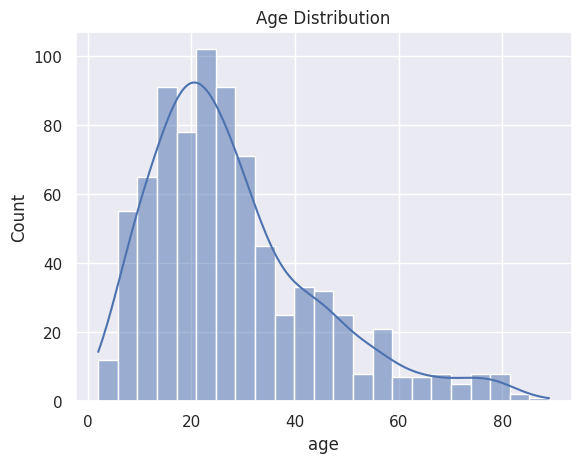

In [135]:
#histogram for age
sns.histplot(train_df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

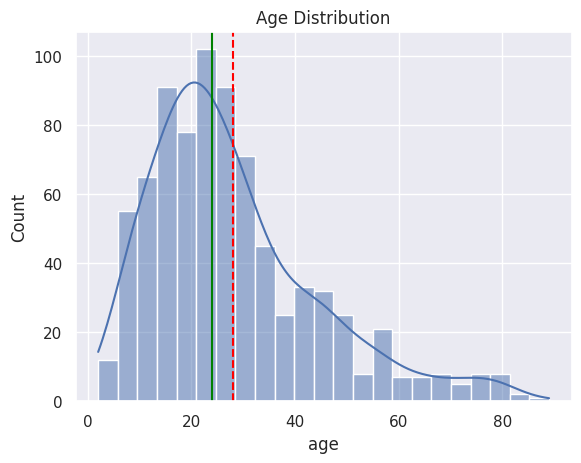

In [136]:
#histogram for age
sns.histplot(train_df["age"], kde=True)
plt.title("Age Distribution")


#calculate mean and median
age_mean = train_df["age"].mean()
age_median = train_df["age"].median()

#add veticak lines for mean and median
plt.axvline(age_mean, color="red", linestyle="--", label="Mean")
plt.axvline(age_median, color="green", linestyle="-", label="Median")

plt.show()

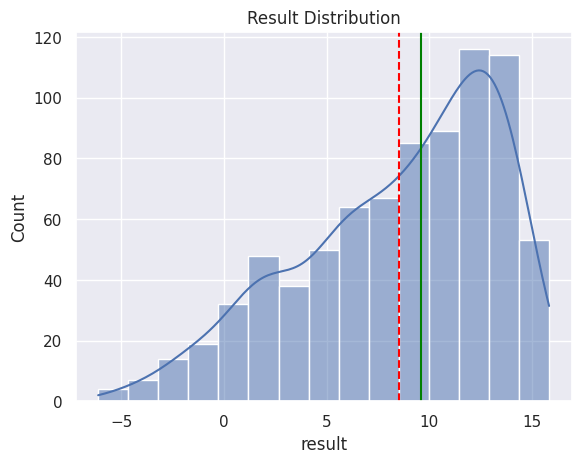

In [137]:
#histogram for age
sns.histplot(train_df["result"], kde=True)
plt.title("Result Distribution")


#calculate mean and median
result_mean = train_df["result"].mean()
result_median = train_df["result"].median()

#add veticak lines for mean and median
plt.axvline(result_mean, color="red", linestyle="--", label="Mean")
plt.axvline(result_median, color="green", linestyle="-", label="Median")

plt.show()

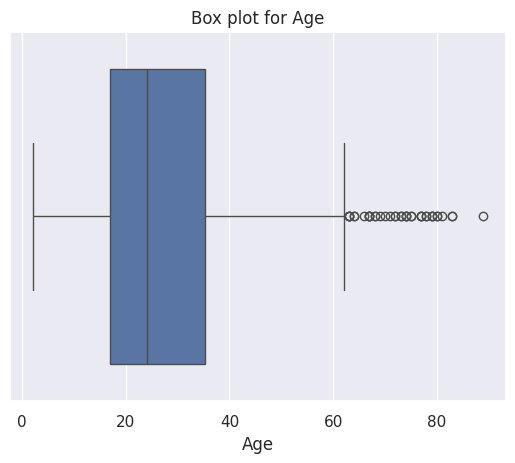

In [138]:
#box plots for identifying outliers in the numerical columns
sns.boxplot(x=train_df["age"])
plt.title("Box plot for Age")
plt.xlabel("Age")
plt.show()

In [139]:
#count the outliers using IQR method
Q1 = train_df["age"].quantile(0.25)
Q3 = train_df["age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

age_outliers = train_df[(train_df["age"] < lower_bound) | (train_df["age"] > upper_bound)]

! Phương pháp IQR (Interquartile Range) là một trong những cách chuẩn và phổ biến nhất để phát hiện các giá trị ngoại lai (outliers) trong tập dữ liệu dựa trên khoảng tứ phân vị.

Kiểm tra thực tế: Với dữ liệu về tuổi, bạn nên kiểm tra kỹ các giá trị ngoại lai này có phải là lỗi nhập liệu hay không (ví dụ: tuổi âm, tuổi quá lớn như 150-200).

Quyết định giữ hay xóa: Nếu đó là các giá trị hợp lệ (ví dụ những người cao tuổi tham gia khảo sát), bạn hoàn toàn có thể giữ lại thay vì tự động xóa, vì thuật toán cây quyết định (Decision Tree, XGBoost) ít bị ảnh hưởng bởi outliers hơn so với các mô hình tuyến tính.

In [140]:
# Xem số lượng và danh sách các dòng bị coi là outliers về tuổi
print("Số lượng dòng ngoại lai:", age_outliers.shape[0])
print(age_outliers["age"])

Số lượng dòng ngoại lai: 39
19     72
31     74
33     67
41     74
92     75
93     79
161    79
231    69
238    64
241    64
262    78
264    78
282    63
320    77
344    68
348    81
352    73
354    80
359    67
440    63
441    73
450    63
460    74
461    79
496    70
508    68
522    67
535    83
582    72
596    75
654    89
656    63
674    67
705    83
714    71
717    77
722    77
747    66
756    80
Name: age, dtype: int64


In [141]:
#count the outliers using IQR method
Q1 = train_df["result"].quantile(0.25)
Q3 = train_df["result"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

result_outliers = train_df[(train_df["result"] < lower_bound) | (train_df["result"] > upper_bound)]

In [142]:
# Xem số lượng và danh sách các dòng bị coi là outliers về result
print("Số lượng dòng ngoại lai:", result_outliers.shape[0])
print(result_outliers["result"])

Số lượng dòng ngoại lai: 1
698   -6.137748
Name: result, dtype: float64


In [143]:
#Uninvariate analysis of Categorical columns
train_df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

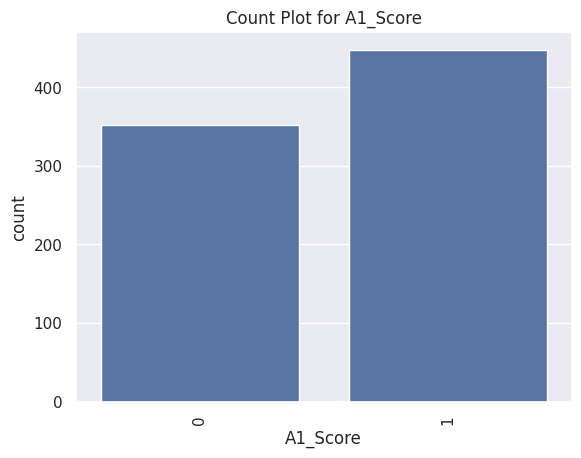

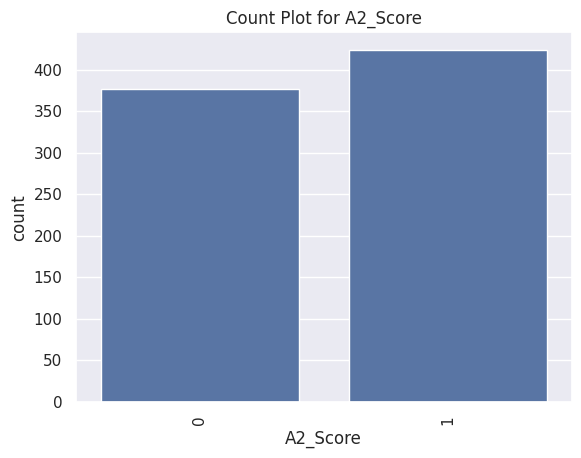

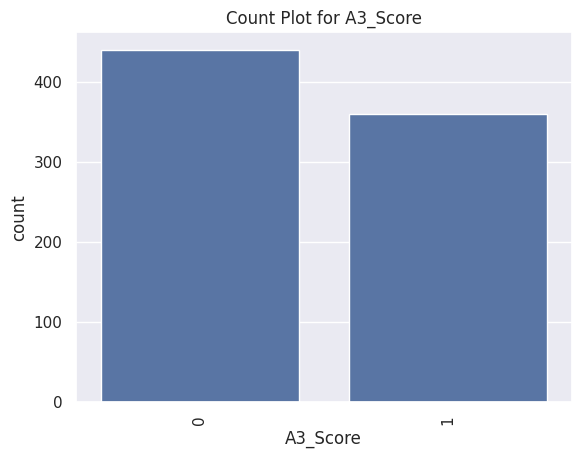

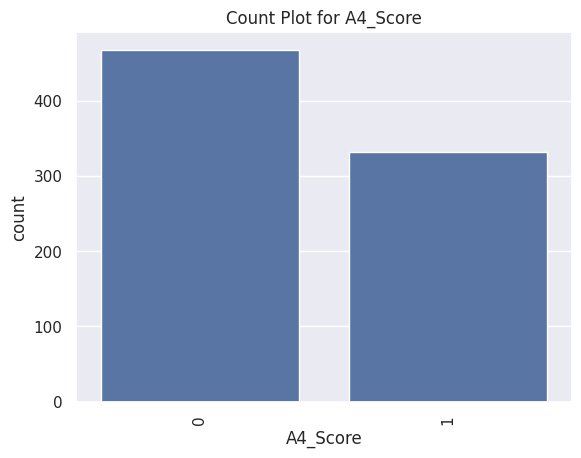

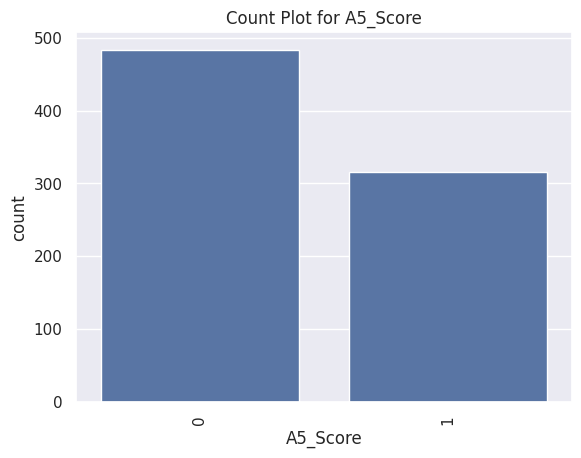

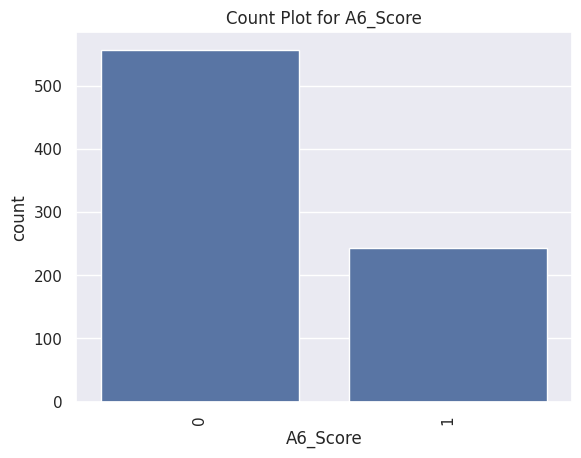

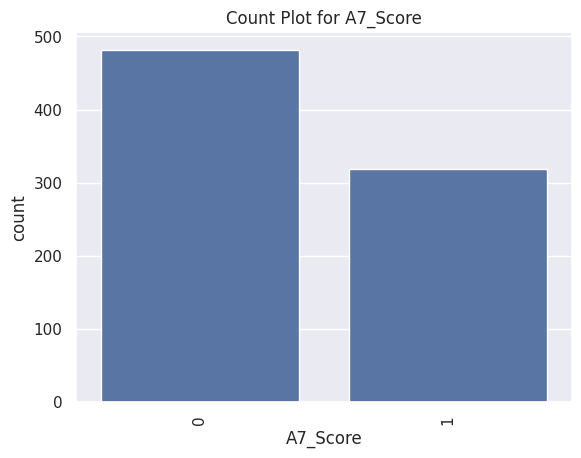

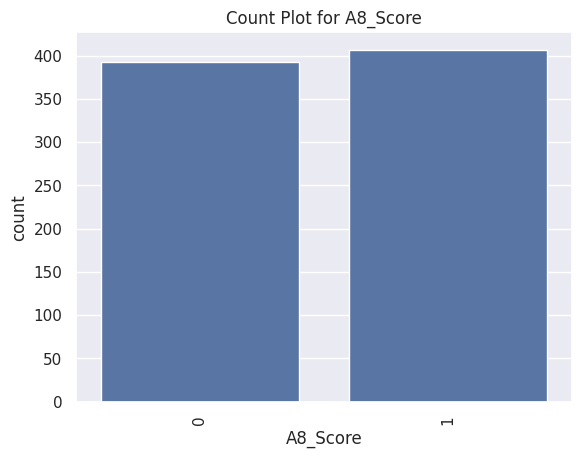

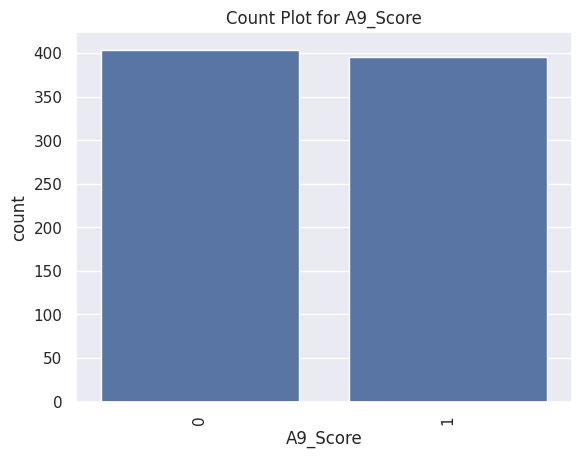

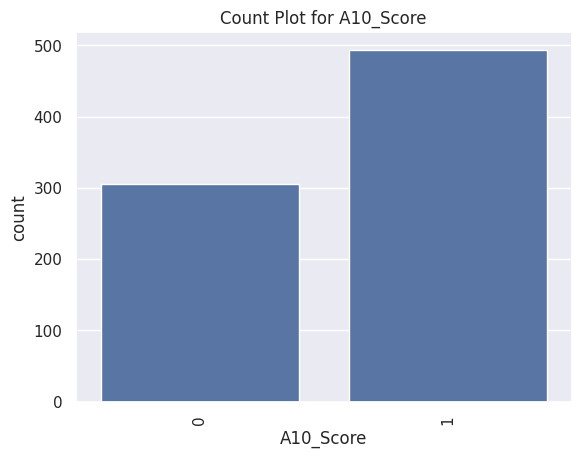

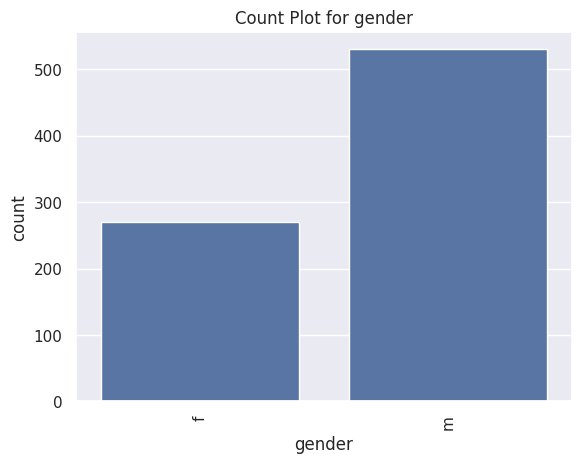

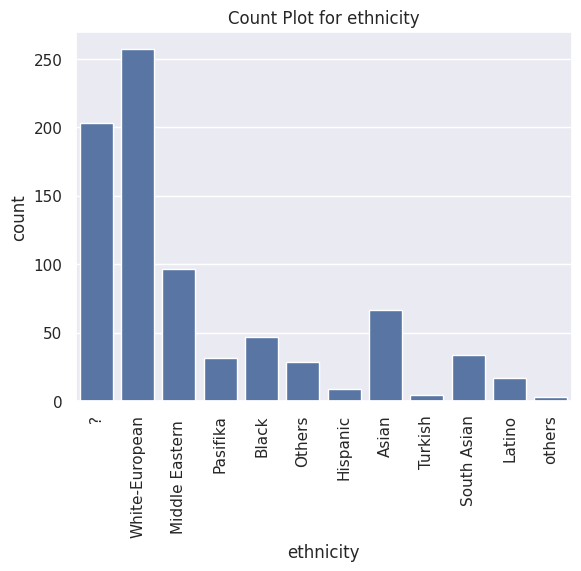

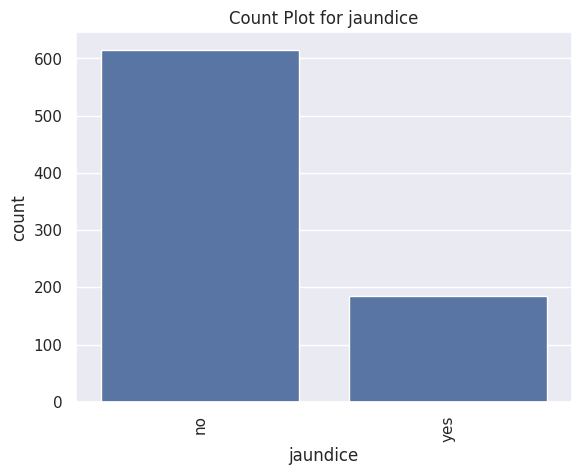

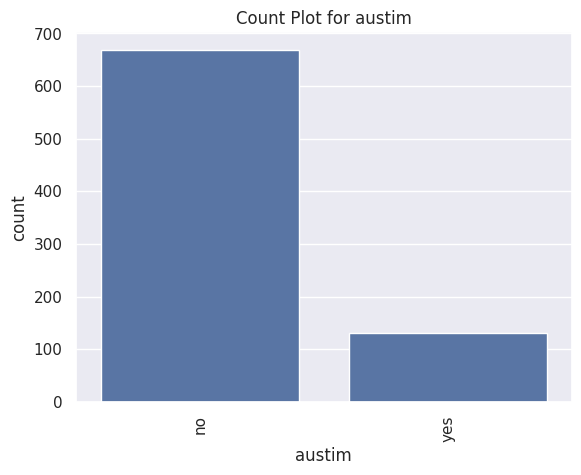

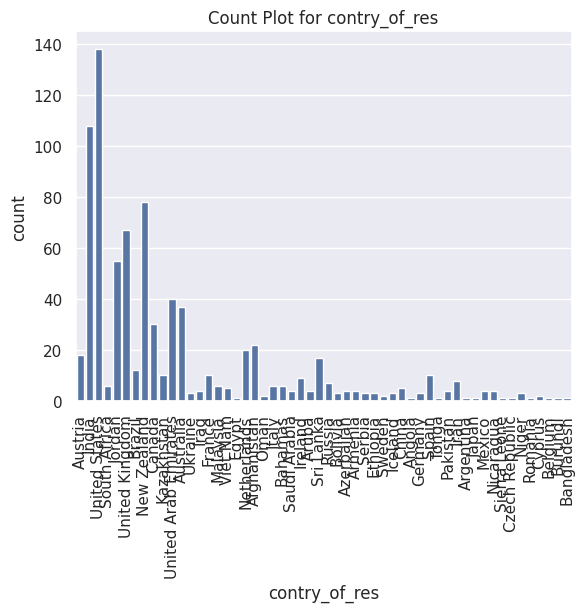

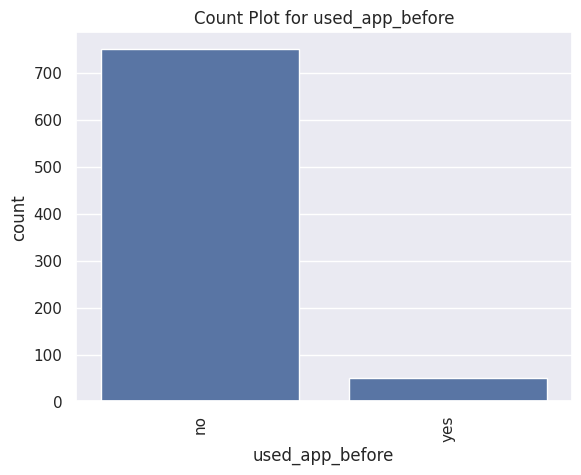

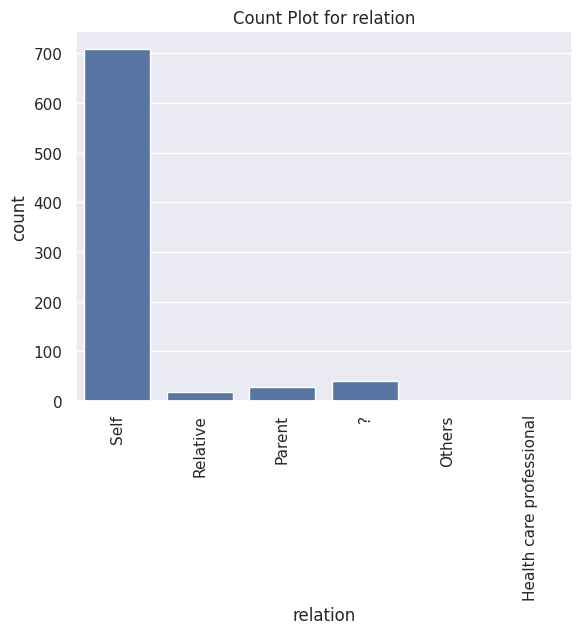

In [144]:
categorical_columns = [
    'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
      'relation'
]

for col in categorical_columns:
  sns.countplot(x=train_df[col])
  plt.title(f"Count Plot for {col}")
  plt.xticks(rotation=90)
  plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

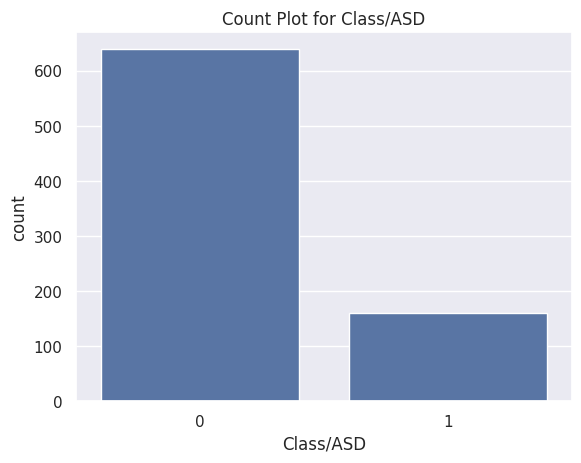

In [145]:
#countplot for target column(Class/ASD)

sns.countplot(x=train_df["Class/ASD"])
plt.title("Count Plot for Class/ASD")
plt.show

In [146]:
train_df["Class/ASD"].value_counts()

,count
Class/ASD,
0,639
1,161


In [147]:
train_df["ethnicity"].unique()

array(['?', 'White-European', 'Middle Eastern ', 'Pasifika', 'Black',
       'Others', 'Hispanic', 'Asian', 'Turkish', 'South Asian', 'Latino',
       'others'], dtype=object)

In [148]:
#handle missing values in ethicity and relation column
train_df["ethnicity"] = train_df["ethnicity"].replace({"?": "Others", "others": "Others"})

In [149]:
train_df["ethnicity"].unique()

array(['Others', 'White-European', 'Middle Eastern ', 'Pasifika', 'Black',
       'Hispanic', 'Asian', 'Turkish', 'South Asian', 'Latino'],
      dtype=object)

In [150]:
train_df["relation"].unique()

array(['Self', 'Relative', 'Parent', '?', 'Others',
       'Health care professional'], dtype=object)

In [151]:
train_df["relation"] = train_df["relation"].replace({"?": "Others", "Relative": "Others", "Parent": "Others", "Health care professional": "Others"})

In [152]:
train_df["relation"].unique()

array(['Self', 'Others'], dtype=object)

In [153]:
train_df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,Others,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,Others,no,no,India,no,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,Others,no,no,United States,no,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,Others,no,no,South Africa,no,-4.777286,Self,0


In [154]:
#Label Encoding
#identify columns with object data type
object_columns = train_df.select_dtypes(include=['object']).columns

In [155]:
object_columns

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='object')

In [156]:
#initialize a dictionary to store the encoders
encoders = {}

#apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  train_df[column] = label_encoder.fit_transform(train_df[column])
  encoders[column] = label_encoder #saveing the encoder for this column

#save the encoders as a pikcle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

Đoạn code bạn vừa viết rất chuẩn và cực kỳ quan trọng trong thực tế! Việc lưu lại từng LabelEncoder vào một dictionary và dump ra file encoders.pkl giúp bạn tái sử dụng chính xác các quy tắc mã hóa đó khi xử lý tập test.csv hoặc khi triển khai mô hình (deployment) cho dữ liệu mới sau này. Tránh được lỗi lệch nhãn hoặc xuất hiện nhãn lạ (unseen labels).

In [157]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

In [158]:
train_df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47,1,5,0,0,23,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7,1,9,0,1,52,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23,0,5,0,0,52,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43,1,5,0,0,44,0,-4.777286,1,0


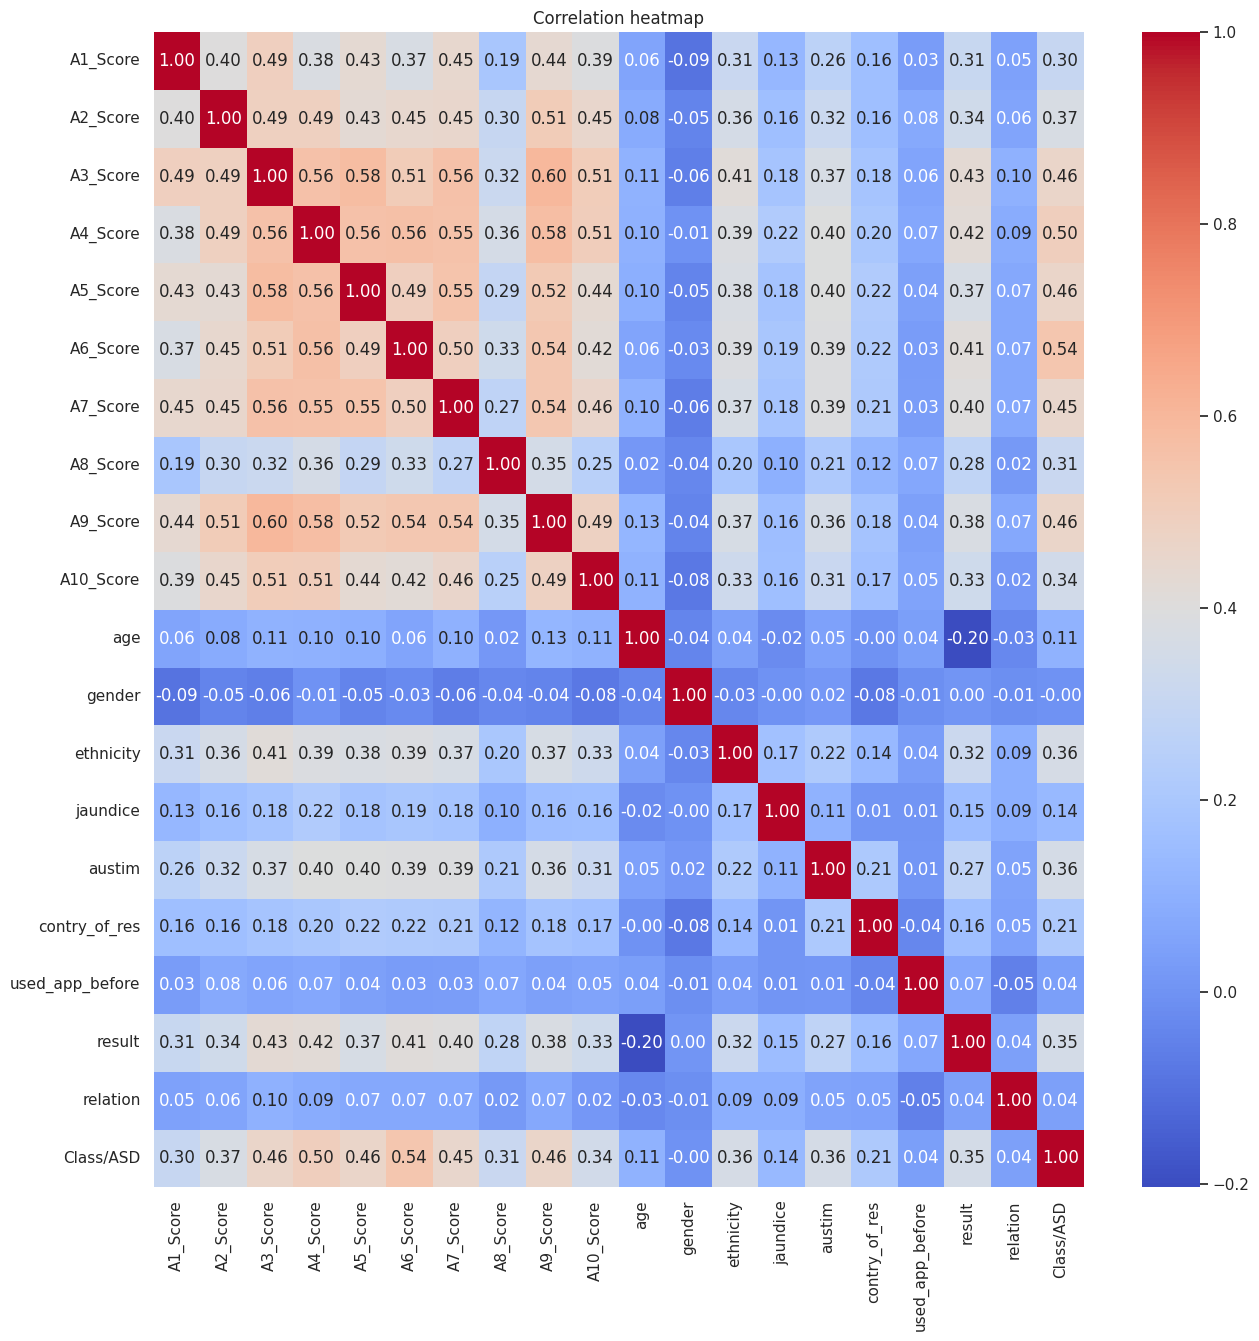

In [159]:
# Biaraiate analysis
#correlation matrix
plt.figure(figsize=(15,15))
sns.heatmap(train_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# Insight from EDA:
- Ther are few outliers in the numerical columns( age, results)
- there is a class imbalance in the target column
- ther is a class imbalance in the categorical feature
- we dont'have any highly correlated column
- perfomed label encoding and sabe the encoders

In [161]:
# Data preprocessing
#function to replace the outliers with median

def replace_outliers_with_median(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR

  median = df[column].median()

  #replace outliers with median value
  df[column] = df[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

  return df

In [162]:
#replace outliers tin the age column
train_df = replace_outliers_with_median(train_df, "age")

#replace outliers in the result column
train_df = replace_outliers_with_median(train_df, "result")

In [163]:
train_df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,23,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,52,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,52,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,44,0,-4.777286,1,0


In [164]:
train_df.shape

(800, 20)

In [165]:
train_df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [166]:
#Train and test split
X = train_df.drop(columns=["Class/ASD"])
y = train_df["Class/ASD"]

In [167]:
X.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,23,0,2.255185,1
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,52,0,14.851484,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,52,0,2.276617,1
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,44,0,-4.777286,1


In [169]:
X.shape

(800, 19)

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [172]:
print(X_train.shape)
print(X_test.shape)

(640, 19)
(160, 19)


In [173]:
y_train.value_counts()

,count
Class/ASD,
0,515
1,125


In [174]:
y_test.value_counts()

,count
Class/ASD,
0,124
1,36


In [175]:
#SMOTE (Synthetic Minority Oversamping rechnique)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Sự tăng lên từ 800 lên 1030 mẫu là hoàn toàn bình thường và chính là bản chất hoạt động của thuật toán SMOTE.

Hãy hiểu cách SMOTE hoạt động qua các điểm sau:SMOTE KHÔNG cân bằng dữ liệu bằng cách nhân bản vô tính (oversampling thông thường), mà nó tự sinh ra (synthetic) các điểm dữ liệu mới nằm giữa các điểm dữ liệu thực tế của lớp thiểu số (minority class).

Mục tiêu của SMOTE là làm cho số lượng mẫu của lớp ít (minority class) bằng với số lượng mẫu của lớp nhiều (majority class).

Giả sử trước khi dùng SMOTE, tập X_train của bạn có tổng cộng 800 mẫu, chia thành:Lớp nhiều (Class 0): Ví dụ có khoảng 515 mẫu.Lớp ít (Class 1): Ví dụ chỉ có khoảng 285 mẫu.

Để kéo số lượng của lớp 1 lên bằng lớp 0 (515 mẫu), SMOTE sẽ phải tạo thêm khoảng $515 - 285 = 230$ mẫu giả lập mới.Tổng số mẫu sau khi cân bằng sẽ là: $515 \text{ (lớp 0)} + 515 \text{ (lớp 1 mới)} = 1030$ mẫu.

In [176]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(1030, 19)
(1030,)


In [179]:
y_train_smote.value_counts()

,count
Class/ASD,
1,515
0,515


In [182]:
#Model Training

from sklearn.ensemble import RandomForestClassifier
#dictionary of classifiers
models = {
    "Decistion Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}


In [185]:
#dictionary to store the cross validation results
cv_scores = {}

#perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters ...")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross validation accuracy: {np.mean(scores):.2f}")
  print(f"{model_name} cross validation mean accuracy: {scores.mean()}")
  print("---")


Training Decistion Tree with default parameters ...
Decistion Tree cross validation accuracy: 0.86
Decistion Tree cross validation mean accuracy: 0.8563106796116504
---
Training Random Forest with default parameters ...
Random Forest cross validation accuracy: 0.92
Random Forest cross validation mean accuracy: 0.9194174757281554
---
Training XGBoost with default parameters ...
XGBoost cross validation accuracy: 0.90
XGBoost cross validation mean accuracy: 0.9038834951456309
---


In [186]:
cv_scores

{'Decistion Tree': array([0.7961165 , 0.87864078, 0.87378641, 0.8592233 , 0.87378641]),
 'Random Forest': array([0.90776699, 0.92718447, 0.9223301 , 0.91747573, 0.9223301 ]),
 'XGBoost': array([0.86893204, 0.9223301 , 0.90776699, 0.90776699, 0.91262136])}

Kết quả cv_scores bạn vừa nhận được thể hiện độ chính xác (accuracy) qua phương pháp kiểm định chéo 5 phần (5-Fold Cross-Validation) của 3 mô hình: Decision Tree, Random Forest và XGBoost.

Cách chia dữ liệu (5-Fold): Tập dữ liệu huấn luyện đã qua SMOTE được chia thành 5 phần bằng nhau. Mô hình sẽ được huấn luyện trên 4 phần và dùng phần còn lại để kiểm tra. Quá trình này lặp lại 5 lần để mỗi phần đều được làm tập kiểm tra một lần.

Mỗi mảng chứa 5 giá trị accuracy: Đại diện cho độ chính xác tương ứng trên 5 lần kiểm tra đó (dao động từ 0 đến 1, trong đó 1 là đúng 100%).


So sánh nhanh 3 mô hình dựa trên kết quả:

Decision Tree (Cây quyết định): Các điểm số dao động từ khoảng 0.79 đến 0.88 (trung bình khoảng 85.6%). Đây là mô hình có độ chính xác thấp nhất trong 3 mô hình.

XGBoost: Các điểm số từ khoảng 0.86 đến 0.92 (trung bình khoảng 90.3%). Mô hình này mạnh hơn Decision Tree nhờ kỹ thuật Boosting.

Random Forest (Rừng ngẫu nhiên): Các điểm số rất đồng đều và cao nhất, từ khoảng 0.90 đến 0.927 (trung bình khoảng 91.9%). Điều này cho thấy Random Forest đang là mô hình hoạt động ổn định và có hiệu suất tốt nhất trên bộ dữ liệu này.

In [189]:
# model selecion & hyperparameter tuning

#initializing models
decistion_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
xgboost_clasifier = XGBClassifier(random_state=42)

In [188]:
#hyperparameter grids for RandomSearchCV

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10,20,30,50,70],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2 , 4]
}

param_grid_rf = {
    "n_estimators": [50,100,200,500],
    "max_depth": [None, 10,20,30,50,70],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1,2,4],
    "bootstrap": [True, False]
}

param_grid_xgb = {
    "n_estimators": [50,100,200,500],
    "max_depth": [3,5,7,10],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.5,0.7,1.0],
    "colsample_bytree": [0.5,0.7,1.0]
}



In [190]:
#hyperparameter tunning for 3 tree based models

#the below steps can be automated by susing a for loop or by susing a pipeline

#perform randomizedSearchCv for each model
random_search_dt = RandomizedSearchCV(
    estimator=decistion_tree,
    param_distributions=param_grid_dt,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search_rf = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgboost_clasifier,
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42
)


In [191]:
#fit the models
random_search_dt.fit(X_train_smote, y_train_smote)
random_search_rf.fit(X_train_smote, y_train_smote)
random_search_xgb.fit(X_train_smote, y_train_smote)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [195]:
print(random_search_dt.best_estimator_)
print(random_search_dt.best_score_)

print(random_search_rf.best_estimator_)
print(random_search_rf.best_score_)

print(random_search_xgb.best_estimator_)
print(random_search_xgb.best_score_)

DecisionTreeClassifier(criterion='entropy', max_depth=30, random_state=42)
0.8699029126213592
RandomForestClassifier(bootstrap=False, max_depth=70, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, random_state=42)
0.9174757281553398
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_paral

In [197]:
#get the model best score

best_model = None
best_score = 0

if random_search_dt.best_score_ > best_score:
  best_model = random_search_dt.best_estimator_
  best_score = random_search_dt.best_score_

if random_search_rf.best_score_ > best_score:
  best_model = random_search_rf.best_estimator_
  best_score = random_search_rf.best_score_

if random_search_xgb.best_score_ > best_score:
  best_model = random_search_xgb.best_estimator_
  best_score = random_search_xgb.best_score_


In [198]:
print(f"best model; {best_model}")
print(f"best score: {best_score:.2f}")

best model; RandomForestClassifier(bootstrap=False, max_depth=70, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, random_state=42)
best score: 0.92


In [200]:
#save the best model
with open("best_model.pkl", "wb") as f:
  pickle.dump(best_model, f)

In [205]:
#evalute on test data
y_test_pred = best_model.predict(X_test)
print("Accuracy score", accuracy_score(y_test, y_test_pred))
print("Confision Matrix", confusion_matrix(y_test, y_test_pred))
print("classification Report", classification_report(y_test, y_test_pred))

Accuracy score 0.8375
Confision Matrix [[108  16]
 [ 10  26]]
classification Report               precision    recall  f1-score   support

           0       0.92      0.87      0.89       124
           1       0.62      0.72      0.67        36

    accuracy                           0.84       160
   macro avg       0.77      0.80      0.78       160
weighted avg       0.85      0.84      0.84       160

